
# Финальная работа по Machine Learning

## Тема
**Прогнозирование энергопотребления спортивного клуба и обнаружение аномалий**

Этот проект соответствует требованиям задания: новый датасет, описание признаков, EDA, предобработка, анализ временного ряда не менее чем 5 ML-подходами, поиск аномалий, визуализации и структура для GitHub.  
Требования задания: выбрать новый датасет, описать признаки, сделать EDA, предобработку, решить сегментацию или временной ряд не менее 5 подходами ML, отдельно решить задачу поиска аномалий и добавить визуализации. fileciteturn1file0



## 1. Описание датасета

Датасет **Smart Club Energy Dataset** является синтетическим, но реалистичным набором данных, моделирующим почасовое энергопотребление спортивного клуба в течение 120 дней.

### Признаки
- `timestamp` - дата и время наблюдения.
- `temperature` - температура окружающей среды, °C.
- `tennis_activity_index` - индекс нагрузки на корты и клубную активность.
- `hour` - час суток.
- `day_of_week` - день недели (`0` = понедельник, `6` = воскресенье).
- `energy_consumption` - энергопотребление клуба, целевая переменная.

### Особенности данных
- есть суточная сезонность;
- есть недельная сезонность;
- присутствует шум;
- специально добавлены аномальные скачки потребления.


In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True


In [2]:

# Генерация датасета
np.random.seed(42)

date_range = pd.date_range(start='2025-01-01', periods=24*120, freq='h')
hours = date_range.hour.values
days = date_range.dayofweek.values

# Сезонности
# дневная нагрузка выше в дневные и вечерние часы
base_daily = 2 + 1.6*np.sin(2*np.pi*(hours-7)/24) + 0.7*np.sin(4*np.pi*(hours-10)/24)
weekly = np.where(days < 5, 0.8, 0.15)

# Температура и активность клуба
temperature = 14 + 9*np.sin(2*np.pi*date_range.dayofyear.values/365) + np.random.normal(0, 1.8, len(date_range))
ten_activity = np.clip(np.random.normal(4.5 + (hours >= 17)*4.0 + ((days == 5) | (days == 6))*1.5, 1.7, len(date_range)), 0, None)

# Энергопотребление
noise = np.random.normal(0, 0.35, len(date_range))
energy = 4.2 + 0.11*temperature + 0.28*ten_activity + base_daily + weekly + noise

# Внедряем аномалии
anomaly_idx = np.random.choice(len(date_range), size=30, replace=False)
energy = energy.copy()
energy[anomaly_idx] += np.random.uniform(4.5, 7.5, size=len(anomaly_idx))

# Лёгкие пропуски для демонстрации предобработки
missing_temp_idx = np.random.choice(len(date_range), size=20, replace=False)
missing_act_idx = np.random.choice(len(date_range), size=18, replace=False)
temperature = temperature.copy()
ten_activity = ten_activity.copy()
temperature[missing_temp_idx] = np.nan
ten_activity[missing_act_idx] = np.nan

df = pd.DataFrame({
    'timestamp': date_range,
    'temperature': temperature,
    'tennis_activity_index': ten_activity,
    'hour': hours,
    'day_of_week': days,
    'energy_consumption': energy,
})

df.head()


,timestamp,temperature,tennis_activity_index,hour,day_of_week,energy_consumption
0,2025-01-01 00:00:00,15.049006,0.695007,0,2,7.921030
1,2025-01-01 01:00:00,13.906044,0.894810,1,2,8.061037
2,2025-01-01 02:00:00,15.320760,3.468329,2,2,8.373688
3,2025-01-01 03:00:00,16.896374,5.278067,3,2,8.809133
4,2025-01-01 04:00:00,13.733444,0.000000,4,2,7.416831


In [3]:

# Сохраняем датасет для GitHub-структуры проекта
from pathlib import Path
out_path = Path('../data/smart_club_energy_dataset.csv')
out_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path, index=False)
out_path


PosixPath('../data/smart_club_energy_dataset.csv')

## 2. Первичный анализ данных (EDA)

In [4]:
print('Размер датасета:', df.shape)
print('\nТипы данных:')
print(df.dtypes)
print('\nКоличество пропусков:')
print(df.isna().sum())


Размер датасета: (2880, 6)

Типы данных:
timestamp                datetime64[ns]
temperature                     float64
tennis_activity_index           float64
hour                              int32
day_of_week                       int32
energy_consumption              float64
dtype: object

Количество пропусков:
timestamp                 0
temperature              20
tennis_activity_index    18
hour                      0
day_of_week               0
energy_consumption        0
dtype: int64


In [5]:

df.describe(include='all').T


,count,mean,min,25%,50%,75%,max,std
timestamp,2880,2025-03-01 23:30:00,2025-01-01 00:00:00,2025-01-30 23:45:00,2025-03-01 23:30:00,2025-03-31 23:15:00,2025-04-30 23:00:00,NaN
temperature,2860.0,20.52162,9.859759,18.379847,21.087892,22.927056,28.553801,3.23477
tennis_activity_index,2862.0,6.037251,0.0,4.144682,5.742666,7.852718,15.358496,2.599265
hour,2880.0,11.5,0.0,5.75,11.5,17.25,23.0,6.923389
day_of_week,2880.0,2.991667,0.0,1.0,3.0,5.0,6.0,1.994069
energy_consumption,2880.0,10.824043,7.370031,9.699761,10.69469,11.865752,20.35652,1.525988


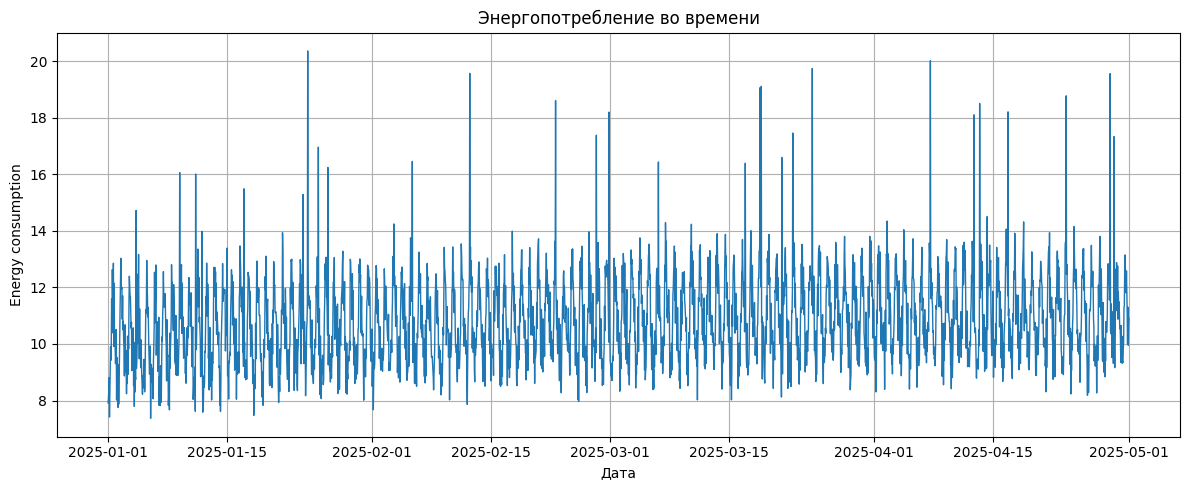

In [6]:

fig, ax = plt.subplots()
ax.plot(df['timestamp'], df['energy_consumption'], linewidth=1)
ax.set_title('Энергопотребление во времени')
ax.set_xlabel('Дата')
ax.set_ylabel('Energy consumption')
plt.tight_layout()
plt.show()


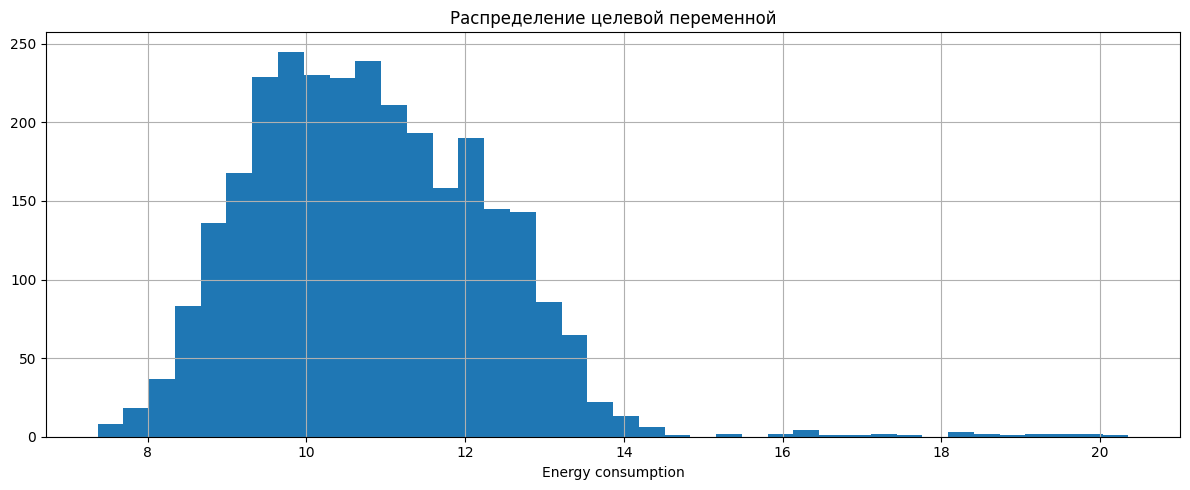

In [7]:

fig, ax = plt.subplots()
ax.hist(df['energy_consumption'], bins=40)
ax.set_title('Распределение целевой переменной')
ax.set_xlabel('Energy consumption')
plt.tight_layout()
plt.show()


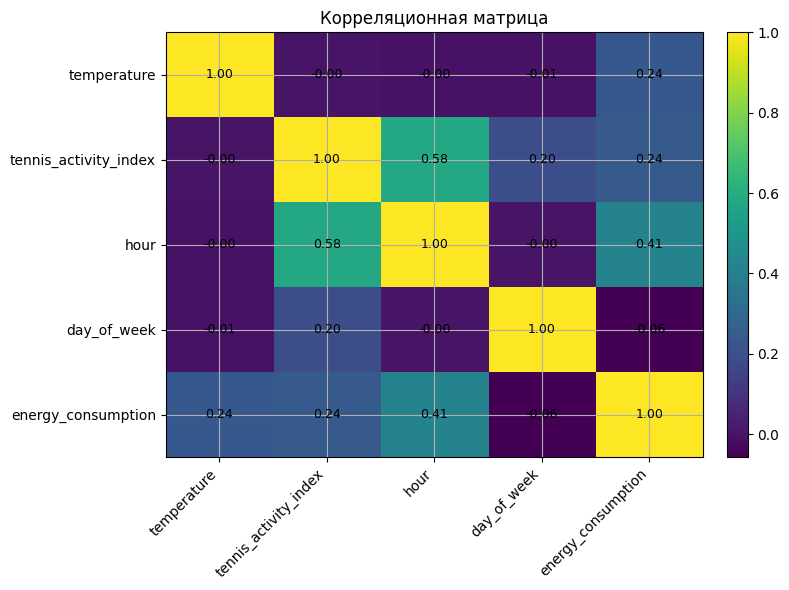

In [8]:

eda_df = df.copy()
eda_df['temperature'] = eda_df['temperature'].interpolate().bfill().ffill()
eda_df['tennis_activity_index'] = eda_df['tennis_activity_index'].interpolate().bfill().ffill()

corr = eda_df[['temperature','tennis_activity_index','hour','day_of_week','energy_consumption']].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(corr, aspect='auto')
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)), corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('Корреляционная матрица')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


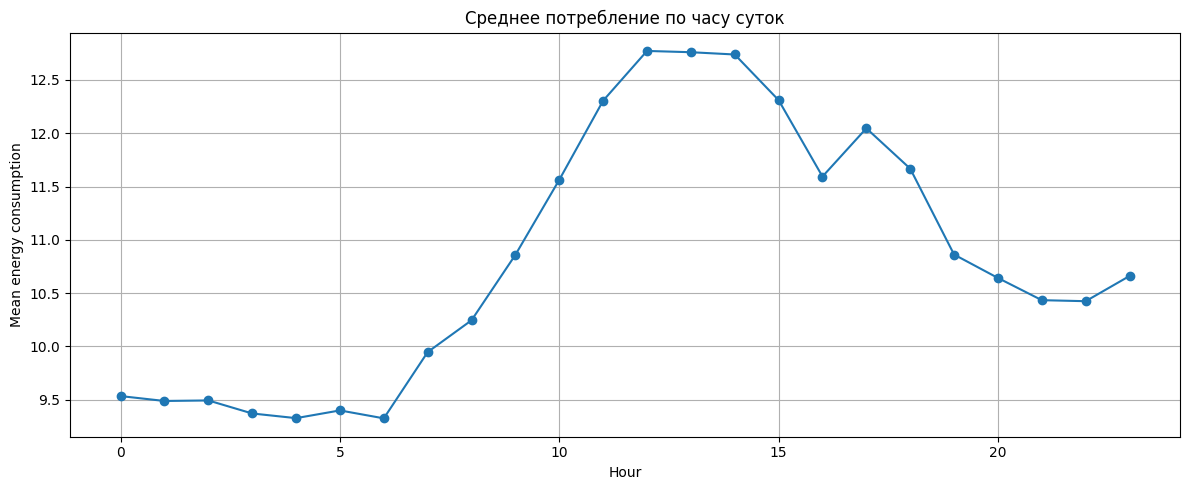

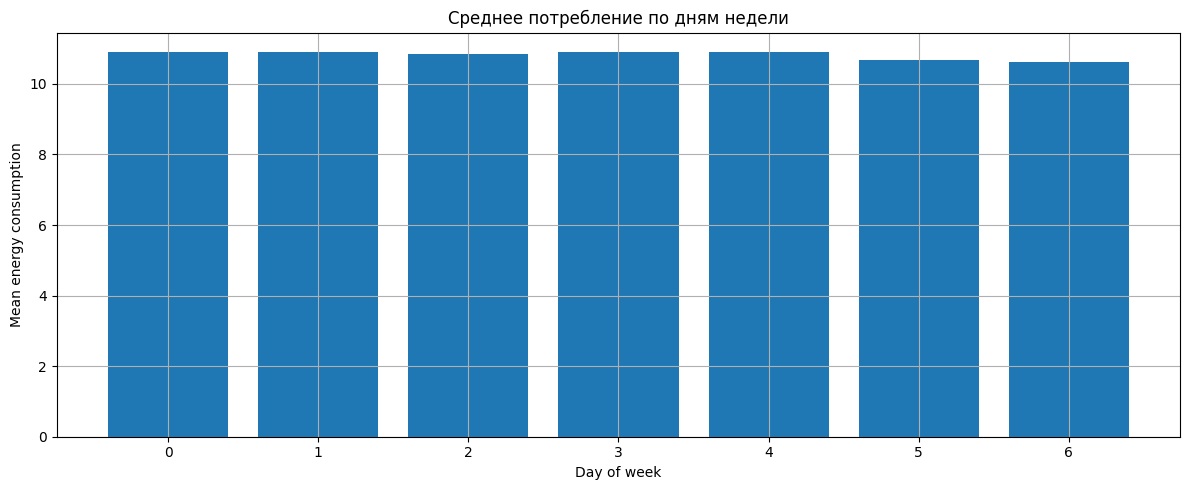

In [9]:

hourly_profile = eda_df.groupby('hour', as_index=False)['energy_consumption'].mean()
weekday_profile = eda_df.groupby('day_of_week', as_index=False)['energy_consumption'].mean()

fig, ax = plt.subplots()
ax.plot(hourly_profile['hour'], hourly_profile['energy_consumption'], marker='o')
ax.set_title('Среднее потребление по часу суток')
ax.set_xlabel('Hour')
ax.set_ylabel('Mean energy consumption')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.bar(weekday_profile['day_of_week'], weekday_profile['energy_consumption'])
ax.set_title('Среднее потребление по дням недели')
ax.set_xlabel('Day of week')
ax.set_ylabel('Mean energy consumption')
plt.tight_layout()
plt.show()



### Краткие выводы по EDA
- временной ряд имеет выраженную суточную сезонность;
- в будние дни среднее энергопотребление выше;
- наблюдаются отдельные резкие пики, похожие на аномалии;
- температура и индекс активности связаны с целевой переменной.


## 3. Предварительная обработка данных

In [10]:

prep = df.copy()
prep['temperature'] = prep['temperature'].interpolate().bfill().ffill()
prep['tennis_activity_index'] = prep['tennis_activity_index'].interpolate().bfill().ffill()
prep['is_weekend'] = (prep['day_of_week'] >= 5).astype(int)

# Лаговые и rolling-признаки
prep['lag_1'] = prep['energy_consumption'].shift(1)
prep['lag_24'] = prep['energy_consumption'].shift(24)
prep['lag_48'] = prep['energy_consumption'].shift(48)
prep['rolling_mean_24'] = prep['energy_consumption'].shift(1).rolling(24).mean()
prep['rolling_std_24'] = prep['energy_consumption'].shift(1).rolling(24).std()

prep = prep.dropna().reset_index(drop=True)
prep.head()


,timestamp,temperature,tennis_activity_index,hour,day_of_week,energy_consumption,is_weekend,lag_1,lag_24,lag_48,rolling_mean_24,rolling_std_24
0,2025-01-03 00:00:00,15.083090,7.182801,0,4,10.677120,0,10.103597,8.016523,7.921030,10.158421,1.510292
1,2025-01-03 01:00:00,11.291105,6.175264,1,4,8.990364,0,10.677120,9.520213,8.061037,10.269279,1.442355
2,2025-01-03 02:00:00,15.047928,5.977563,2,4,9.775852,0,8.990364,8.431369,8.373688,10.247202,1.458286
3,2025-01-03 03:00:00,13.771429,3.725583,3,4,9.027060,0,9.775852,9.014698,8.809133,10.303222,1.410541
4,2025-01-03 04:00:00,13.246117,2.988291,4,4,8.239061,0,9.027060,7.758046,7.416831,10.303737,1.410052


In [11]:

feature_cols = [
    'temperature', 'tennis_activity_index', 'hour', 'day_of_week', 'is_weekend',
    'lag_1', 'lag_24', 'lag_48', 'rolling_mean_24', 'rolling_std_24'
]
X = prep[feature_cols]
y = prep['energy_consumption']

split_index = int(len(prep) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

timestamps_test = prep['timestamp'].iloc[split_index:]

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)


Train shape: (2265, 10)
Test shape: (567, 10)


## 4. Обучение моделей (не менее 5 подходов ML)

In [12]:

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Lasso': Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.001, max_iter=10000))]),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': Pipeline([('scaler', StandardScaler()), ('model', SVR(C=8.0, epsilon=0.08, kernel='rbf'))]),
}

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    mae, rmse, r2 = evaluate_model(y_test, pred)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2
0,Gradient Boosting,0.474838,0.904697,0.664304
1,Random Forest,0.479871,0.920499,0.652474
2,SVR,0.501472,0.951921,0.628343
3,Lasso,0.652680,1.084247,0.517834
4,Ridge,0.652530,1.084335,0.517756
5,Linear Regression,0.652491,1.084357,0.517736


In [13]:

best_model_name = results_df.loc[0, 'Model']
best_pred = predictions[best_model_name]
print('Лучшая модель по RMSE:', best_model_name)


Лучшая модель по RMSE: Gradient Boosting


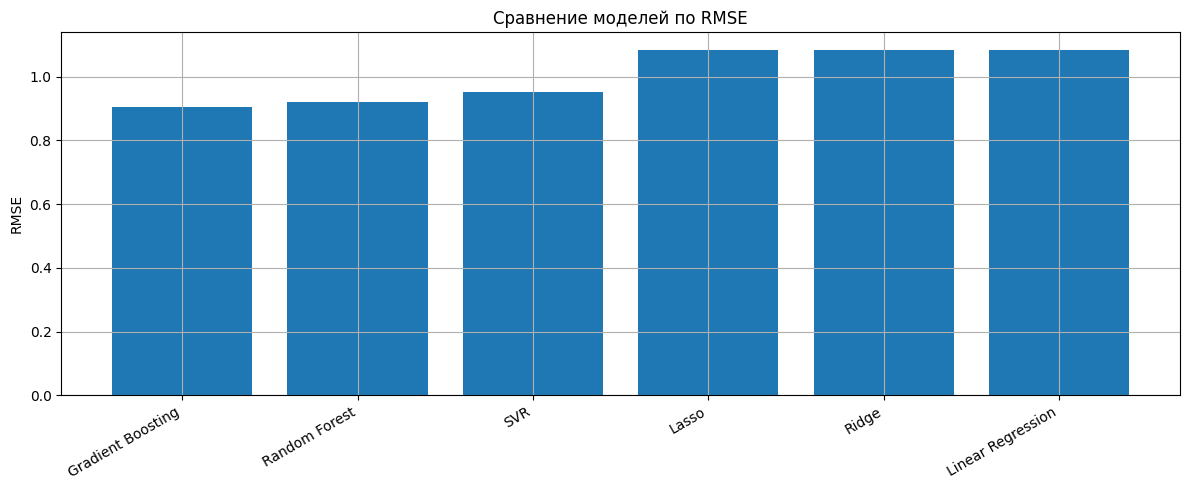

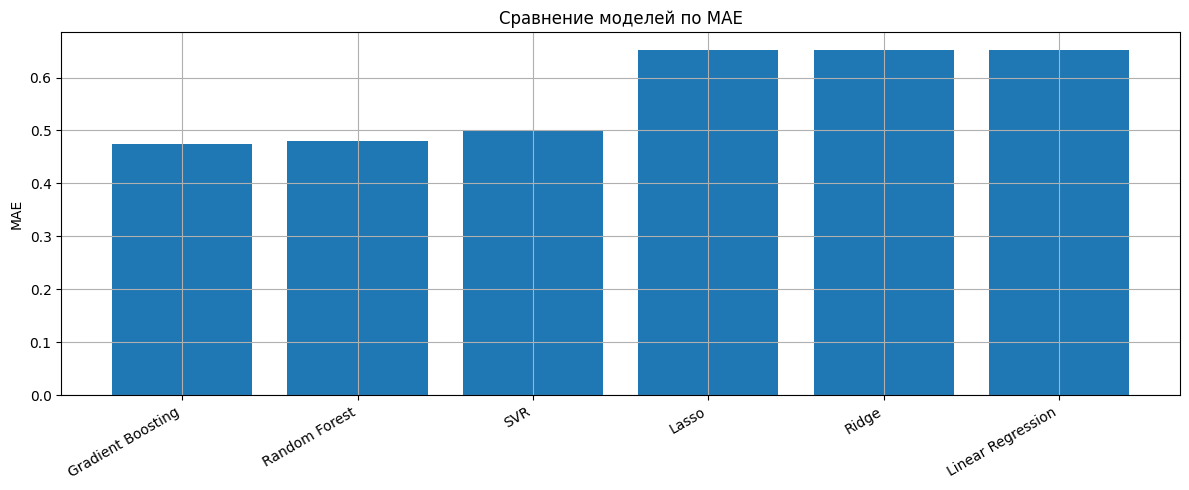

In [14]:

fig, ax = plt.subplots()
ax.bar(results_df['Model'], results_df['RMSE'])
ax.set_title('Сравнение моделей по RMSE')
ax.set_ylabel('RMSE')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.bar(results_df['Model'], results_df['MAE'])
ax.set_title('Сравнение моделей по MAE')
ax.set_ylabel('MAE')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 5. Визуализация прогноза и ошибок

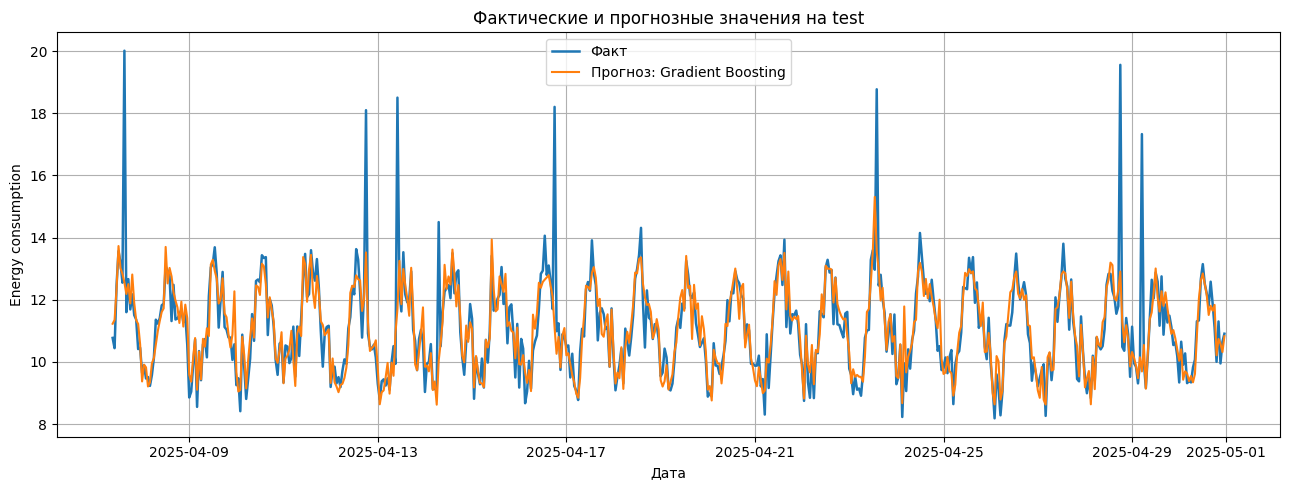

In [15]:

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(timestamps_test.values, y_test.values, label='Факт', linewidth=1.8)
ax.plot(timestamps_test.values, best_pred, label=f'Прогноз: {best_model_name}', linewidth=1.5)
ax.set_title('Фактические и прогнозные значения на test')
ax.set_xlabel('Дата')
ax.set_ylabel('Energy consumption')
ax.legend()
plt.tight_layout()
plt.show()


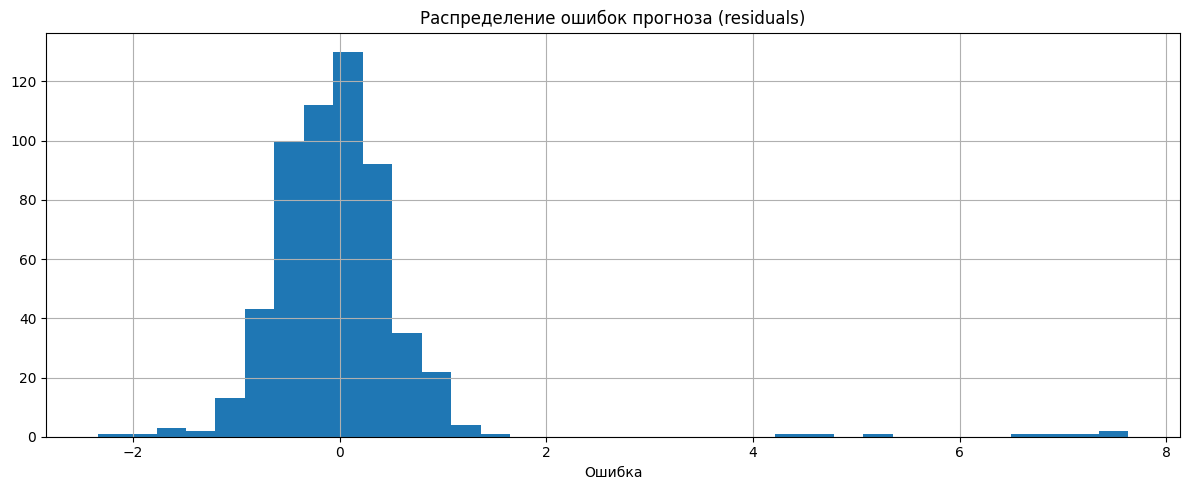

In [16]:

residuals = y_test.values - best_pred
fig, ax = plt.subplots()
ax.hist(residuals, bins=35)
ax.set_title('Распределение ошибок прогноза (residuals)')
ax.set_xlabel('Ошибка')
plt.tight_layout()
plt.show()


In [17]:

rf = models['Random Forest']
rf.fit(X_train, y_train)
feature_importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
feature_importances


,feature,importance
7,lag_48,0.344425
2,hour,0.198789
6,lag_24,0.161768
1,tennis_activity_index,0.107206
0,temperature,0.069369
5,lag_1,0.051364
8,rolling_mean_24,0.024480
9,rolling_std_24,0.018661
3,day_of_week,0.016948
4,is_weekend,0.006990


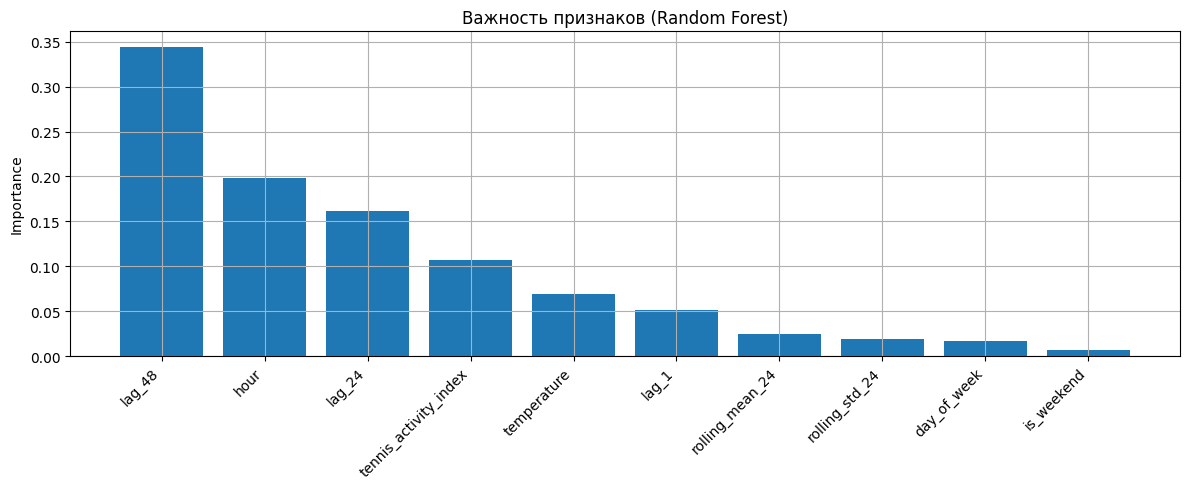

In [18]:

fig, ax = plt.subplots()
ax.bar(feature_importances['feature'], feature_importances['importance'])
ax.set_title('Важность признаков (Random Forest)')
ax.set_ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 6. Поиск аномалий

In [19]:

anom_features = prep[feature_cols + ['energy_consumption']].copy()
iso = IsolationForest(contamination=0.012, random_state=42)
prep['anomaly_label'] = iso.fit_predict(anom_features)
prep['is_anomaly'] = (prep['anomaly_label'] == -1).astype(int)

prep['is_anomaly'].value_counts()


is_anomaly
0    2798
1      34
Name: count, dtype: int64

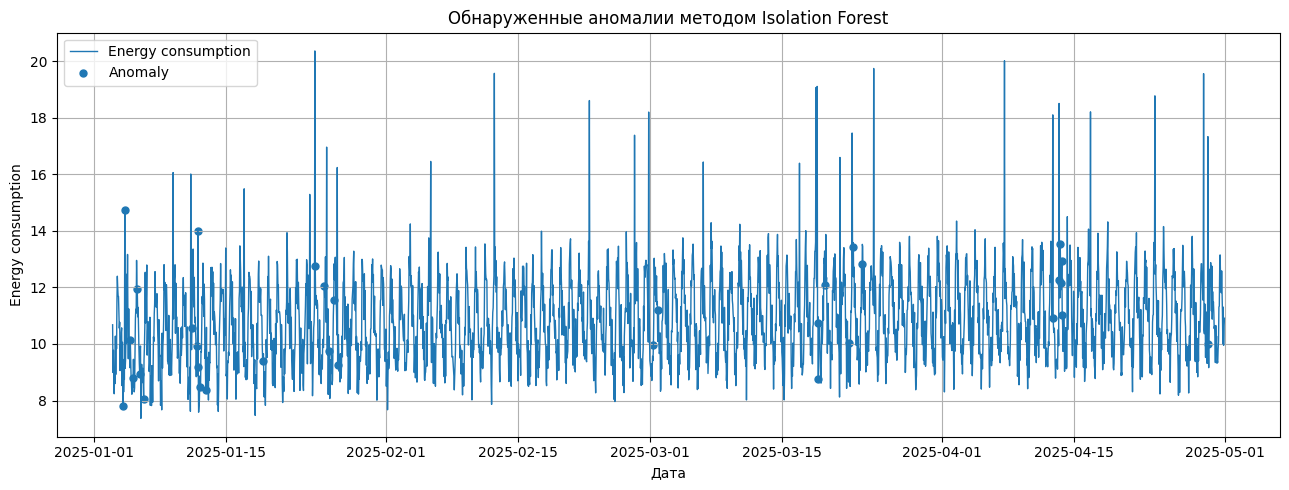

In [20]:

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(prep['timestamp'], prep['energy_consumption'], label='Energy consumption', linewidth=1)
mask = prep['is_anomaly'] == 1
ax.scatter(prep.loc[mask, 'timestamp'], prep.loc[mask, 'energy_consumption'], s=25, label='Anomaly')
ax.set_title('Обнаруженные аномалии методом Isolation Forest')
ax.set_xlabel('Дата')
ax.set_ylabel('Energy consumption')
ax.legend()
plt.tight_layout()
plt.show()



## 7. Итоговые выводы

1. Для задачи временного ряда был создан новый датасет, связанный с энергопотреблением спортивного клуба.
2. Проведён EDA: изучены распределения, сезонность, корреляции и поведение ряда во времени.
3. Выполнена предобработка: обработка пропусков, генерация календарных, лаговых и rolling-признаков.
4. Обучено 6 моделей: Linear Regression, Ridge, Lasso, Random Forest, Gradient Boosting и SVR.
5. Лучшая модель определяется по RMSE на тестовой выборке.
6. Задача поиска аномалий решена методом Isolation Forest.
7. Проект полностью готов к размещению в GitHub-репозитории.
